## seq2seq Model

Sequence‑to‑Sequence (Seq2Seq) models are neural networks designed to transform one sequence into another, even when the input and output lengths differ and are built using encoder‑decoder architecture.

* It processes an input sequence and generates a corresponding output sequence.
* Handles variable‑length input and output sequences
* It is used in NLP, machine translation, speech recognition and time-series prediction.

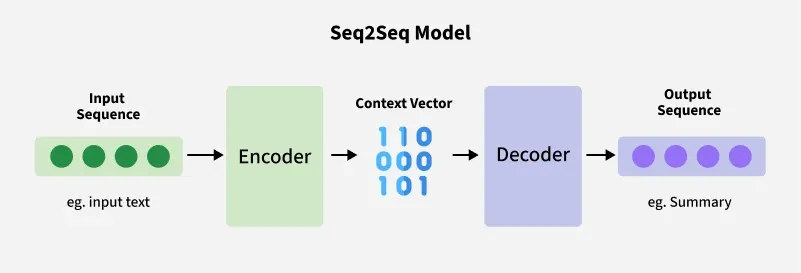

Both the input and the output are treated as sequences of varying lengths and the model is composed of two parts:

**1. Encoder:**

* Processes the input sequence token by token.
* Encodes the entire sequence into a fixed-length context vector (or a series of hidden states) that summarizes the important information from the input.

**2. Decoder:**

* Takes the context vector as input.
* Generates the output sequence one token at a time, predicting each token based on the context vector and previously generated tokens.

The model is commonly used in tasks where there is a need to map sequences of varying lengths such as converting a sentence in one language to another or predicting a sequence of future events based on past data i.e time-series forecasting.

### Seq2Seq with RNNs

In traditional Seq2Seq models, Recurrent Neural Networks (RNNs) are used for both the encoder and decoder. The encoder processes the input sequence and produces a context vector, which is then passed to the decoder to generate the output sequence based on following equations:

$$\begin{align*}
h_t &= f(h_{t-1}, x_t) \
c &= h_T \\
s_t &= g(s_{t-1}, y_{t-1}, c) \
y_t &= \text{softmax}(Ws_t + b)
\end{align*}$$

Where:
* $h_t$ is the hidden state of the encoder at time step $t$.
* $x_t$ is the input token at time step $t$.
* $c$ is the context vector (the final hidden state of the encoder).    
* $s_t$ is the hidden state of the decoder at time step $t$.
* $y_{t-1}$ is the previously generated token at time step $t-1$.
* $W$ and $b$ are the weights and bias for the output layer of the decoder.

**Limitations of Vanilla RNNs:**

* Vanilla RNNs struggle with long-term dependencies due to the vanishing gradient problem.
* To overcome this, advanced RNN variants like LSTM (Long Short-Term Memory) or GRU (Gated Recurrent Unit) are used in Seq2Seq models. These architectures are better at capturing long-range dependencies.

## How Does the Seq2Seq Model Work?

A Sequence-to-Sequence (Seq2Seq) model consists of two primary phases: encoding the input sequence and decoding it into an output sequence.

### 1. Encoding Phase

* The encoder processes the input sequence token by token, updating its internal state at each step.
* After processing the entire sequence, the encoder produces a context vector i.e a fixed-length representation summarizing the important information from the input.

### 2. Decoding Phase

The decoder takes the context vector and generates the output sequence one token at a time. For example, in machine translation:

* Input: "I am learning"
* Output: "Je suis apprenant"

Each token is predicted based on the context vector and previously generated tokens.

### 3. Teacher Forcing

During training, teacher forcing is commonly used. Instead of feeding the decoder’s own previous prediction as the next input, the actual target token from the training data is provided.

**Benefits:**

* Accelerates training
* Reduces error propagation

Teacher forcing is used only during training and not during inference, where the model relies on its own previous predictions.

## Step-by-Step Seq2Seq Implementation
### Step 1: Import libraries

In [10]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F 


### Step 2: Encoder

We will define:

* Each input token is converted to a dense vector (embedding).
* The GRU processes the sequence one token at a time, updating its hidden state.
* The final hidden state is returned as the context vector, summarizing the input sequence.

In [11]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return hidden

### Step 3: Decoder

We will define the decoder:

* Takes the current input token and converts it to an embedding.
* GRU uses the previous hidden state (or context vector initially) to compute the new hidden state.
* The output is passed through a linear layer to get predicted token probabilities.

In [12]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, input, hidden):
        input = input.unsqueeze(0)
        embedded = self.embedding(input)
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.fc(output.squeeze(0))
        return prediction, hidden

### Step 4: Seq2Seq Model with Teacher Forcing

* **Batch size & vocab size:** extracted from input and decoder.
* **Encoding:** input sequence → encoder → context vector (hidden).
* **Start token:** initialize decoder with token 0.
* **Loop over max_len:** Decoder predicts next token.
* **top1:** token with max probability.
* Append top1 to outputs.
* **Teacher forcing:** sometimes feed true target token instead of prediction.
* **Return predictions:** concatenated sequence of token IDs.

In [13]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=10, teacher_forcing_ratio=0.5):
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc.out_features
        outputs = []

        hidden = self.encoder(src)

        input = torch.zeros(batch_size, dtype=torch.long).to(self.device)

        for t in range(max_len):
            output, hidden = self.decoder(input, hidden)
            top1 = output.argmax(1)
            outputs.append(top1.unsqueeze(0))

            if trg is not None and t < trg.shape[0] and torch.rand(1).item() < teacher_forcing_ratio:
                input = trg[t]
            else:
                input = top1

        outputs = torch.cat(outputs, dim=0)
        return outputs

### Step 5: Usage Example with Outputs

Test with example,

* **src:** random input token IDs.
* **trg:** random target token IDs (used for teacher forcing).
* **outputs:** predicted token IDs for each sequence.
* **.T:** transpose to show batch sequences as rows.

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

VOCAB_SIZE = 10
EMB_DIM = 8
HID_DIM = 16
SEQ_LEN = 5
BATCH_SIZE = 2

enc = Encoder(VOCAB_SIZE, EMB_DIM, HID_DIM)
dec = Decoder(VOCAB_SIZE, EMB_DIM, HID_DIM)
model = Seq2Seq(enc, dec, device).to(device)

src = torch.randint(1, VOCAB_SIZE, (SEQ_LEN, BATCH_SIZE)).to(device)
trg = torch.randint(1, VOCAB_SIZE, (SEQ_LEN, BATCH_SIZE)).to(device)

outputs = model(src, trg, max_len=SEQ_LEN, teacher_forcing_ratio=0.7)

print("Source sequence (input tokens):")
print(src.T)
print("\nTarget sequence (true tokens):")
print(trg.T)
print("\nPredicted sequence (model output tokens):")
print(outputs.T)

Source sequence (input tokens):
tensor([[1, 5, 3, 7, 2],
        [6, 8, 7, 5, 7]])

Target sequence (true tokens):
tensor([[5, 5, 7, 1, 4],
        [3, 1, 3, 6, 6]])

Predicted sequence (model output tokens):
tensor([[2, 7, 7, 7, 7],
        [2, 2, 7, 7, 7]])


### Applications
* **Machine Translation:** Converts text between languages like English to French.
* **Text Summarization:** Produces concise summaries of documents or news articles.
* **Speech Recognition:** Transcribes spoken language into text.
* **Image Captioning:** Generates captions for images by combining visual features with sequence generation.
* **Time-Series Prediction:** Predicts future sequences based on past temporal data.

### Advantages
* **Flexibility:** Handles tasks like translation, summarization and captioning with variable-length sequences.
* **Handling Sequential Data:** Ideal for sequential data like natural language, speech and time series.
* **Context Awareness:** Encoder-decoder structure captures input context effectively.
* **Attention Mechanism:** Focuses on important parts of input, improving performance for long sequences.

### Disadvantages
* **Computationally Expensive:** Requires significant resources to train and optimize.
* **Limited Interpretability:** Hard to understand the model's decision-making process.
Overfitting: Prone to overfitting without proper regularization.
Rare Word Handling: Struggles with rare words not seen during training.